#1. Pipelining in Machine Learning

In our previous exercises, we executed each stage of the machine learning workflow (Scaling, Oversampling, and Model Training) as separate, manual steps. While this works for experimentation, it is prone to human error and a critical issue called Data Leakage.

A Pipeline allows us to bundle these sequential steps into a single, cohesive object. Instead of managing multiple datasets (such as X_train_scaled, X_train_resampled), we pass our raw data into the Pipeline, and it handles the transformations automatically.


**Why use a Pipeline?**

* Prevention of Data Leakage: The pipeline ensures that preprocessing (like Scaling) is "fitted" only on the training data and never "peeks" at the test data.

* Code Cleanliness: It reduces boilerplate code, making your notebook easier to read and maintain.

##Example

###1.1. Load Libraries

#### 1.1.1 Install/Update packages

Install/update following packages if loading gives an error.

In [32]:
#pip install --upgrade imbalanced-learn

In [33]:
!pip install --upgrade scipy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.0/35.0 MB 19.7 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3


In [3]:
#!pip install --upgrade scikit-learn

In [4]:
#!pip install --upgrade tensorflow

In [5]:
#!pip install --upgrade requests

#### 1.1.2 Load the required python libraries

*  For general data manipulation and data analysis using machine learning.



In [29]:
#Libraries for data manipulation
import numpy as np
import pandas as pd
import seaborn as sns

#Plotting
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt

#Libraries for data manipulation and validation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier

#Resampling
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler

#Performance matrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

#Classifiers
from sklearn.neighbors import KNeighborsClassifier

Ignore warnings

In [3]:
import warnings

warnings.filterwarnings('ignore')

###1.2. Read data from files

*  Data files can be stored in the google drive or local folder
*  Update the path to the particular file accordingly


In [4]:
# Mounting the drive is not used in the submitted version. Keep this commented
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


####1.2.1 Set File Paths

In [5]:
cycling ="/content/drive/MyDrive/Colab Notebooks/activity3_data/Cycling.csv"
pushup  = "/content/drive/MyDrive/Colab Notebooks/activity3_data/Pushup.csv" # if reading from local folder fails, get from this file ID in google drive
run     = "/content/drive/MyDrive/Colab Notebooks/activity3_data/Run.csv"  # if reading from local folder fails, get from this file ID in google drive
squat   = "/content/drive/MyDrive/Colab Notebooks/activity3_data/Squat.csv" # if reading from local folder fails, get from this file ID in google drive
tennis  = "/content/drive/MyDrive/Colab Notebooks/activity3_data/Table Tenis.csv" # if reading from local folder fails, get from this file ID in google drive
walk    = "/content/drive/MyDrive/Colab Notebooks/activity3_data/Walk.csv"

activityList = ['cycling','pushup','run','squat','tennis','walk'] # list of activities in order of files being read

file_paths =[cycling,pushup,run,squat,tennis,walk]
names = ['X1', 'Y1', 'Z1', 'X2', 'Y2', 'Z2', 'X3', 'Y3', 'Z3', 'X4', 'Y4', 'Z4', 'X5', 'Y5', 'Z5','Activity']


####1.2.2 Open files

* Here we try to read the .csv files from the local drive.
* If not found, it will be downloaded and read from the specified shared google drive


In [6]:
raw_data = [] # List to store data

# Open the file, read data, and append data to to raw_data[] list

for index, path in enumerate(file_paths):
  try:
      raw_data.append(pd.read_csv(path,names=names,skiprows=1))
      print(f"\nFile successfully read from: {path}")
      print("\n --Head--")
      print(raw_data[index].head(2))
      print("\n --Tail--")
      print(raw_data[index].tail(2))
  except Exception as e:
      # Handle the error if reading the CSV file fails
      print("Error reading file:", e)



File successfully read from: /content/drive/MyDrive/Colab Notebooks/activity3_data/Cycling.csv

 --Head--
    X1   Y1   Z1   X2   Y2   Z2   X3   Y3   Z3   X4   Y4   Z4   X5   Y5   Z5  \
0  375  593  378  535  434  424  317  412  437  561  529  379  444  320  429   
1  438  593  381  609  494  482  361  472  496  623  596  395  505  360  488   

  Activity  
0    Cycle  
1    Cycle  

 --Tail--
        X1   Y1   Z1   X2   Y2   Z2   X3   Y3   Z3   X4   Y4   Z4   X5   Y5  \
52444  430  504  458  613  543  536  361  562  538  526  488  417  515  379   
52445  373  457  452  608  538  541  324  542  553  587  478  394  517  366   

        Z5 Activity  
52444  527    Cycle  
52445  529    Cycle  

File successfully read from: /content/drive/MyDrive/Colab Notebooks/activity3_data/Pushup.csv

 --Head--
      X1     Y1     Z1     X2     Y2     Z2     X3     Y3     Z3     X4  \
0  346.0  461.0  434.0  572.0  436.0  489.0  406.0  529.0  488.0  509.0   
1  374.0  493.0  464.0  561.0  556.0  529.

*   It seems like there are NULL values

###1.3 Explore data



*   We need to combine the datasets for analysis.
*   However, before combining we have to identify the size of data points (instances) and the type of data in each column (feature).



#### 1.3.1 Size of data sets

In [7]:
for activity, df in zip(activityList, raw_data):
    print(f"{activity}: {df.shape}")

cycling: (52446, 16)
pushup: (14448, 16)
run: (9987, 16)
squat: (14448, 16)
tennis: (67699, 16)
walk: (20300, 16)


In [8]:
for activity, df in zip(activityList, raw_data):
    print(f"\n{activity}")
    print(df.info())
    print("\n")


cycling
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52446 entries, 0 to 52445
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   X1        52446 non-null  int64 
 1   Y1        52446 non-null  int64 
 2   Z1        52446 non-null  int64 
 3   X2        52446 non-null  int64 
 4   Y2        52446 non-null  int64 
 5   Z2        52446 non-null  int64 
 6   X3        52446 non-null  int64 
 7   Y3        52446 non-null  int64 
 8   Z3        52446 non-null  int64 
 9   X4        52446 non-null  int64 
 10  Y4        52446 non-null  int64 
 11  Z4        52446 non-null  int64 
 12  X5        52446 non-null  int64 
 13  Y5        52446 non-null  int64 
 14  Z5        52446 non-null  int64 
 15  Activity  52446 non-null  object
dtypes: int64(15), object(1)
memory usage: 6.4+ MB
None



pushup
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14448 entries, 0 to 14447
Data columns (total 16 columns):
 #   Column    Non-Null

We have to check the labels for consistency

#### 1.3.2 Label consistency

In [9]:
for df in raw_data:
  print('\n-----------------')
  print(df['Activity'].unique())


-----------------
['Cycle']

-----------------
['Push-up' nan 'Pushup']

-----------------
['Run']

-----------------
['Squat' nan]

-----------------
['Table Tenis']

-----------------
['Walk']


*   In the label column of squat data file, there are NULL values along with the label.
* We need to remove the NULL labels


**We have to consider the following in our data preperation.**
* Activity is the class
* There are 6 classes
* Features are acellerometer readings
* There are 15 features
* Class need to be predicted **given an instance of the accellerometer readings**
* An instance of the accellerometer readings is the accelerometer readings of a particular point of time



###1.4 Prepare Data

#### 1.4.1 Combine Datasets


In [10]:
# Prepare the 'dataset' by concatinating individual datasets
dataset = pd.concat(raw_data, ignore_index=True)
# Shape of the combined dataset
print("Shape of combined dataset:", dataset.shape)
print('\nSummary of Data:\n')
print(dataset.groupby('Activity').size())

Shape of combined dataset: (179328, 16)

Summary of Data:

Activity
Cycle          52446
Push-up         5794
Pushup          1049
Run             9987
Squat          12229
Table Tenis    67699
Walk           20300
dtype: int64


####1.4.2 Clean Data

#####1.4.2.1 Remove Nulls

##### Check for Null values

In [11]:
data = dataset.copy()
print(data.isna().sum())
print("\nShape of data before removing NULLs:", data.shape)

X1          9824
Y1          9824
Z1          9824
X2          9824
Y2          9824
Z2          9824
X3          9824
Y3          9824
Z3          9824
X4          9824
Y4          9824
Z4          9824
X5          9824
Y5          9824
Z5          9824
Activity    9824
dtype: int64

Shape of data before removing NULLs: (179328, 16)


There are NULL values among features and labels.  They have to be removed

##### Remove Null values and check again

In [12]:
data.dropna(inplace=True)
print(data.isna().sum())

print("\nShape of data after removing NULLs:", data.shape)

X1          0
Y1          0
Z1          0
X2          0
Y2          0
Z2          0
X3          0
Y3          0
Z3          0
X4          0
Y4          0
Z4          0
X5          0
Y5          0
Z5          0
Activity    0
dtype: int64

Shape of data after removing NULLs: (169504, 16)



*   It can be observed that all the NULL values are removed



#####1.4.2.2 Remove duplicates

Whether we need to remove the duplicates depends on the application. In acelleroeter data, can we have a two time instances with with same acellerometer readings. Probably Yes.
*   We have to decide whether to remove the duplicates or not later on
*   For the time being, we will not remove the duplicates

However, there can be zero rows which we may need to remove.

In [13]:
dups = data.duplicated()
print("Number of duplicated rows:", dups.sum())
#Printing rduplicated rows
unique_from_dups = data[dups].drop_duplicates(keep='first')
print(unique_from_dups)

Number of duplicated rows: 85
           X1     Y1     Z1     X2     Y2     Z2     X3     Y3     Z3     X4  \
66902   392.0  543.0  476.0  641.0  506.0  540.0  382.0  515.0  541.0  635.0   
66909   393.0  546.0  473.0  643.0  506.0  542.0  383.0  513.0  540.0  634.0   
66924   393.0  544.0  474.0  643.0  506.0  542.0  383.0  513.0  540.0  635.0   
66934   394.0  545.0  473.0  643.0  506.0  542.0  383.0  513.0  540.0  635.0   
66955   394.0  546.0  475.0  643.0  506.0  542.0  383.0  513.0  540.0  635.0   
66965   394.0  546.0  474.0  643.0  506.0  542.0  383.0  513.0  540.0  634.0   
66970   394.0  545.0  475.0  643.0  506.0  542.0  383.0  513.0  540.0  634.0   
66972   394.0  545.0  475.0  643.0  506.0  542.0  383.0  513.0  540.0  634.0   
66984   394.0  546.0  475.0  643.0  505.0  541.0  383.0  512.0  540.0  634.0   
66986   394.0  546.0  475.0  643.0  505.0  541.0  383.0  512.0  540.0  634.0   
69829   394.0  543.0  467.0  643.0  480.0  528.0  382.0  497.0  538.0  633.0   
69898   39

In [14]:
#dups = data.duplicated() # identify duplicating rows
#print("Number of duplicates removed:", dups.sum())
#data = data[~dups] # remove duplicates from data

#print("\nShape of data after removing NULLs:", data.shape)

#### 1.4.3 Encode the labels

* Other than label, all 15 features contain neumerical data.
* Only the label column needs encoding



**View Unique Labels**

In [20]:
print(data['Activity'].value_counts())

Activity
Table Tenis    67699
Cycle          52446
Walk           20300
Squat          12229
Run             9987
Push-up         5794
Pushup          1049
Name: count, dtype: int64


* Now, we can see thre are two labels for the same activity: "Pushup" and "Push-up".
* We have to combine them to one label. That is, replace one label with the other.

**Correctine the Labels**

In [15]:
data['Activity'] = data['Activity'].replace("Push-up", "Pushup")
print(data['Activity'].value_counts())

Activity
Table Tenis    67699
Cycle          52446
Walk           20300
Squat          12229
Run             9987
Pushup          6843
Name: count, dtype: int64


**Encode the Labels**

In [17]:
labelEncodedData = data.copy() #making a copy of data
# Encode the Activity column
LE = LabelEncoder()
labelEncodedData['Activity'] = LE.fit_transform(labelEncodedData['Activity'])

encodedLabels = []
print("Label mapping:")
for i, label in enumerate(LE.classes_):
    print(f"{i} → {label}")
    encodedLabels.append(label)

Label mapping:
0 → Cycle
1 → Pushup
2 → Run
3 → Squat
4 → Table Tenis
5 → Walk


#### 1.4.4 View the distribution of feature values (OPtional)

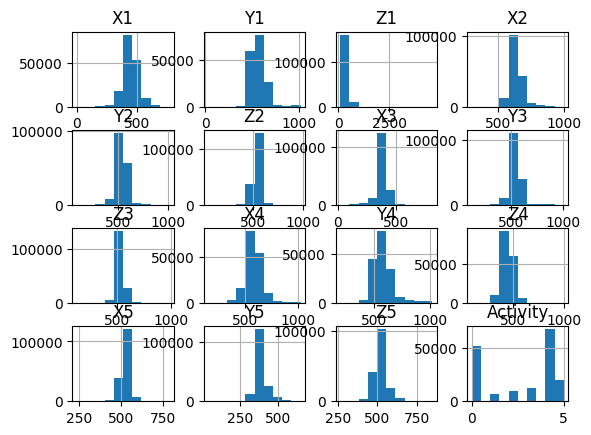

In [18]:
labelEncodedData.hist()
plt.show() #Display the histogram of values

*  Most of the feature values are ecentered around 500
*  Only Z1 andY5 are different
*  All the values are between 0 and 1000






#### 1.4.5 Identify the correlations between features as well as the labels (Optional)

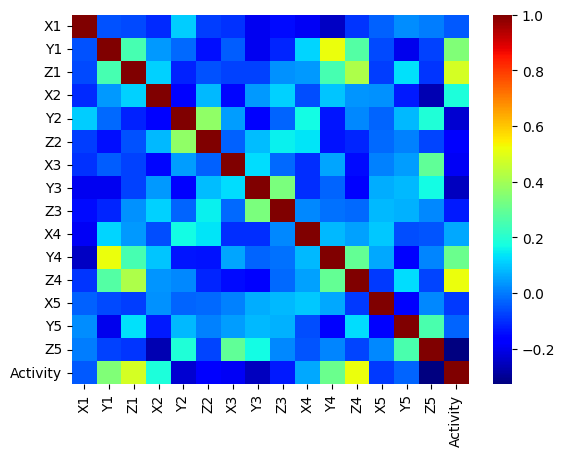

In [19]:
matrix = labelEncodedData.corr() # Get the correlation matrix
sns.heatmap(matrix,cmap="jet") # set the heatmap colour
plt.show() # should the heatmap


*   It can be observed that Y1, Z1, X2, X4, Y4, Z4 are correlated with the Activity than the rest of the features
*   Hence, we can predict the Sensor 1 and Sensor 4 would be contributing to the classification than the other sensors

###1.5 Split Data into Train and Test Sets

####1.5.1 View the Class Distribution Before Splitting

In [20]:
print("Class distribution before balancing the data set:")
print("------------------------------------------------:")
print(labelEncodedData['Activity'].value_counts())

Class distribution before balancing the data set:
------------------------------------------------:
Activity
4    67699
0    52446
5    20300
3    12229
2     9987
1     6843
Name: count, dtype: int64


####1.5.2 Split Data

In [21]:
Features = labelEncodedData.drop("Activity", axis=1)  # Features
Labels = labelEncodedData["Activity"]  # Target (0 = No Diabetes, 1 = Diabetes)

# Split the data into training and testing sets
X_1_train, X_1_test, Y_1_train, Y_1_test = train_test_split(Features, Labels, test_size=0.20, random_state=1)

print("\nTrain Class Distribution")
print("------------------------")
print(Y_1_train.value_counts())

print("\nTest Class Distribution")
print("------------------------")
print(Y_1_test.value_counts())


Train Class Distribution
------------------------
Activity
4    54310
0    41942
5    16102
3     9713
2     8045
1     5491
Name: count, dtype: int64

Test Class Distribution
------------------------
Activity
4    13389
0    10504
5     4198
3     2516
2     1942
1     1352
Name: count, dtype: int64


###1.6 Define and Fit the Pipeline for Scale Data. Re-Sample, and Train Data

####1.6.1 Define the Pipeline for Scale Data. Re-Sample, and Train Data

In [22]:
from imblearn.pipeline import Pipeline

In [23]:
# This bundles scaling, oversampling, and the model into one 'engine'
pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('oversampler', RandomOverSampler(sampling_strategy='all', random_state=42)),
    #('oversampler', RandomUnderSampler(sampling_strategy='all', random_state=42)),
    ('knn', KNeighborsClassifier())
])

####1.6.2 Fit the pipeline using the RAW training data
The pipeline will:
* Fit the scaler on X_1_train and transform it
* Oversample the resulting data
* Train the KNN model

In [24]:
pipeline.fit(X_1_train, Y_1_train)

Pipeline(steps=[('scaler', MinMaxScaler()),
                ('oversampler',
                 RandomOverSampler(random_state=42, sampling_strategy='all')),
                ('knn', KNeighborsClassifier())])

###1.7 Predict using the RAW test data

In [25]:
y_pred = pipeline.predict(X_1_test)

###1.8 Evaluate the Performance

In [26]:
accuracy = accuracy_score(Y_1_test, y_pred)
conf_matrix = confusion_matrix(Y_1_test, y_pred)
report = classification_report(Y_1_test, y_pred)

print(f"Model Accuracy (Single Split): {accuracy:.4f}")
print("\nConfusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", report)

Model Accuracy (Single Split): 0.9896

Confusion Matrix:
 [[10463     1     1    29     8     2]
 [    0  1352     0     0     0     0]
 [    0     0  1931     0     5     6]
 [    1     0     0  2515     0     0]
 [   64    18    43    13 13100   151]
 [    0     0     2     1     7  4188]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99     10504
           1       0.99      1.00      0.99      1352
           2       0.98      0.99      0.99      1942
           3       0.98      1.00      0.99      2516
           4       1.00      0.98      0.99     13389
           5       0.96      1.00      0.98      4198

    accuracy                           0.99     33901
   macro avg       0.98      0.99      0.99     33901
weighted avg       0.99      0.99      0.99     33901



#2. Model Validation in Machine Learning

**Common Methods of Validation**

There are several strategies to assess model performance, ranging from simple splits to more robust iterative processes:

1. **Train/Test Split (Holdout Method)**: The dataset is split into two parts (e.g., 80% training, 20% testing). The model learns from the training set, and its "final grade" is determined by the test set.

2. **Train/Validation/Test Split**: A three-way split. The validation set is used to tune hyperparameters (like the depth of a tree), while the test set remains locked away until the very end to provide an unbiased evaluation.

3. **Bootstrapping**: Repeatedly sampling from the dataset with replacement to estimate the uncertainty of the model performance.

#3.Cross-Validation (CV)

##3.1 What is Cross-Validation

Cross-Validation is a more sophisticated technique used to protect against "lucky" or "unlucky" splits in a simple train/test shuffle. Instead of splitting the data once, CV splits the data multiple times and averages the results.

**The most common version is k-Fold Cross-Validation**:

1. The data is divided into k equal-sized subsets (folds).
2. The model is trained k times.
3. In each iteration, one fold is used as the test set (validation), and the remaining $k-1$ folds are used for training.
4. The final performance score is the average of the scores from all k iterations.

##3.2 How Cross-Validation fits into Model Validation

Cross-validation is often considered the "gold standard" of model validation during the development phase for several reasons:

1. **Reduced Variance**: Because the model is tested on every single data point eventually, the performance metric is much more reliable than a single train/test split.

2. **Efficiency with Small Data**: If you have a small dataset, a simple test split might leave you with too little data to train on. CV allows you to use all your data for both training and validation.

3. **Hyperparameter Tuning**: CV is the primary tool used in methods like GridSearchCV or RandomizedSearchCV in Scikit-Learn to find the best settings for a model without overfitting to a specific subset of data.

### Example

In [27]:
from sklearn.model_selection import cross_val_score

# Apply 5-fold cross validation
# Note: We pass the WHOLE dataset (Features, Labels)
# Note: If we tune the hyper parameters, we should only apply training set
# Cross_val_score handles the splitting for us internally.to whatever the data we input
cv_scores = cross_val_score(pipeline, Features, Labels, cv=5)

# Output the results
print("--- 5-Fold Cross Validation Results ---")
print(f"Accuracy for each fold: {cv_scores}")
print(f"Mean Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")

--- 5-Fold Cross Validation Results ---
Accuracy for each fold: [0.96516327 0.97070883 0.95902776 0.94775965 0.9120354 ]
Mean Accuracy: 0.9509
Standard Deviation: 0.0209


In [32]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_1_train, Y_1_train)


RandomForestClassifier(random_state=42)

In [33]:
y_pred = model.predict(X_1_test)
accuracy = accuracy_score(Y_1_test, y_pred)
print(accuracy)


0.9932155393646205
